In [1]:
!pip install docling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.0/506.0 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 69.7 MB/s eta 0:00:00
   ━━

In [2]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

# **Picture Extraction**

* This step loads the PDF and extracts all images into (doc.pictures).

In [3]:
pipeline_options = PdfPipelineOptions()
pipeline_options.generate_picture_images = True
pipeline_options.images_scale = 2

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

result = converter.convert("https://arxiv.org/pdf/2501.17887")
doc = result.document

[INFO] 2026-05-10 22:05:42,895 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 22:05:42,902 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 22:05:42,908 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.8.0/torch/PP-OCRv4/det/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 22:05:44,035 [RapidOCR] download_file.py:82: Download size: 13.83MB
[INFO] 2026-05-10 22:05:44,301 [RapidOCR] download_file.py:95: Successfully saved to: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 22:05:44,304 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 22:05:44,652 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 22:05:44,653 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 22:05:44,655 [RapidOCR] download_file.py:68: Initiating download: https

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

In [4]:
print("Number of pictures extracted from the document:", len(doc.pictures))

Number of pictures extracted from the document: 6


* Display the extracted pictures from the PDF file:

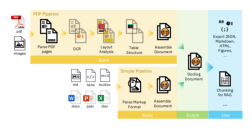

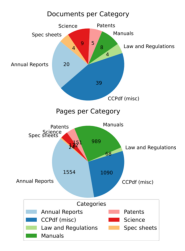

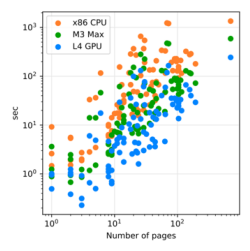

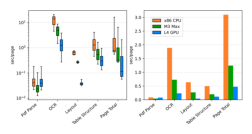

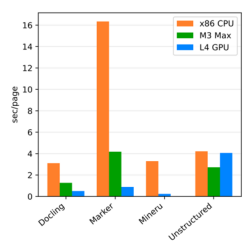

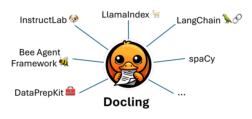

In [5]:
import matplotlib.pyplot as plt

for i, pic in enumerate(doc.pictures):
    plt.figure(figsize=(3, 3))
    plt.imshow(pic.get_image(doc))
    plt.axis("off")
    plt.show()

* Print Basic Metadata for Each Extracted Picture:

In [6]:
for i, pic in enumerate(doc.pictures):
    print(f"Picture {i}")
    print("Page Number:", pic.prov[0].page_no)
    print("Image Size:", pic.image.size)
    print("-" * 40)

Picture 0
Page Number: 2
Image Size: width=846.0 height=397.0
----------------------------------------
Picture 1
Page Number: 5
Image Size: width=415.0 height=579.0
----------------------------------------
Picture 2
Page Number: 5
Image Size: width=331.0 height=331.0
----------------------------------------
Picture 3
Page Number: 7
Image Size: width=803.0 height=395.0
----------------------------------------
Picture 4
Page Number: 7
Image Size: width=378.0 height=376.0
----------------------------------------
Picture 5
Page Number: 7
Image Size: width=463.0 height=198.0
----------------------------------------


# **Task 1: Picture Classification**

* This code loads the PDF, extracts its pictures, and applies classification to label each image:

In [7]:
pipeline_options = PdfPipelineOptions()
pipeline_options.generate_picture_images = True
pipeline_options.images_scale = 2
pipeline_options.do_picture_classification = True

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

result = converter.convert("https://arxiv.org/pdf/2501.17887")
doc = result.document

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[INFO] 2026-05-10 22:07:01,171 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 22:07:01,173 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 22:07:01,222 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 22:07:01,224 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 22:07:01,462 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 22:07:01,463 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 22:07:01,470 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-10 22:07:01,471 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-10 22:07:01,573 [Ra

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

* Picture Classification Output:


In [8]:
for item, level in doc.iterate_items():

    if item.label == "picture":
        print("\nPICTURE:")

        if hasattr(item, "annotations"):
          for annotation in item.annotations:
            if annotation.kind == "classification":
               top = annotation.predicted_classes[0]
               print("Predicted Class:", top.class_name)
               print("Confidence Score:", top.confidence)


PICTURE:
Predicted Class: flow_chart
Confidence Score: 0.7514168620109558

PICTURE:
Predicted Class: pie_chart
Confidence Score: 0.9735286235809326

PICTURE:
Predicted Class: scatter_plot
Confidence Score: 0.9932158589363098

PICTURE:
Predicted Class: bar_chart
Confidence Score: 0.9907111525535583

PICTURE:
Predicted Class: bar_chart
Confidence Score: 0.9996851682662964

PICTURE:
Predicted Class: flow_chart
Confidence Score: 0.35088062286376953


/tmp/ipykernel_11538/4269578308.py:6: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  if hasattr(item, "annotations"):
/tmp/ipykernel_11538/4269578308.py:7: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  for annotation in item.annotations:


# **Task 2: Picture Description**

* This code loads the PDF, extracts its pictures, and generates descriptions for each image:

In [9]:
# from docling.datamodel.pipeline_options import granite_picture_description

# pipeline_options = PdfPipelineOptions()
# pipeline_options.do_picture_description = True
# pipeline_options.picture_description_options = granite_picture_description

# converter = DocumentConverter(format_options={
#     InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
# })

# result = converter.convert("https://arxiv.org/pdf/2501.17887")
# doc = result.document

Loading weights:   0%|          | 0/815 [00:00<?, ?it/s]

[INFO] 2026-05-10 21:14:51,740 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 21:14:51,742 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 21:14:51,792 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 21:14:51,793 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 21:14:52,061 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 21:14:52,063 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 21:14:52,069 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-10 21:14:52,070 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-10 21:14:52,175 [Ra

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [10]:
from docling.datamodel.pipeline_options import smolvlm_picture_description

pipeline_options = PdfPipelineOptions()
pipeline_options.do_picture_description = True
pipeline_options.generate_picture_images = False
pipeline_options.picture_description_options = smolvlm_picture_description

converter = DocumentConverter(format_options={
    InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
})

result = converter.convert("https://arxiv.org/pdf/2501.17887")
doc = result.document

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

[INFO] 2026-05-10 22:22:31,091 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 22:22:31,092 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 22:22:31,140 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 22:22:31,142 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-10 22:22:31,402 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-10 22:22:31,404 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-10 22:22:31,409 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-10 22:22:31,410 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-10 22:22:31,514 [Ra

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

KeyboardInterrupt: 

* Picture Description Output:


In [ ]:
for item, level in doc.iterate_items():

    if item.label != "picture":
        continue

    print("\nPICTURE DESCRIPTION:")

    if hasattr(item, "annotations"):
        for annotation in item.annotations:
            if annotation.kind == "description":
                print(annotation.description)

# **Summary of Picture Metadata, Descriptions, and Classification Results:**

In [ ]:
for i, pic in enumerate(doc.pictures):
    print(f"\nPicture {i}")
    print("Page Number:", pic.prov[0].page_no)

    # Description
    if hasattr(pic, "caption_text"):
        description = pic.caption_text(doc)
    else:
        description = "No description available"
    print("Description:", description)


    # Classification
    if hasattr(pic.meta, "classification") and pic.meta.classification.predictions:
        top = pic.meta.classification.predictions[0]
        print("Top Classification:", top.class_name)
        print("Confidence Score:", top.confidence)
    else:
        print("Top Classification: None")
        print("Confidence Score: None")

    print("-" * 40)